In [3]:
import cx_Oracle
import itertools
import joblib
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
# import missingno as msno

In [638]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import  accuracy_score,roc_auc_score,average_precision_score,f1_score,precision_score,recall_score,classification_report,confusion_matrix
from xgboost import XGBClassifier
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from functools import  reduce
from sklearn.tree import DecisionTreeClassifier

In [5]:
%matplotlib inline
sns.set_style('whitegrid')
from matplotlib import font_manager
# font_path='/usr/share/fonts/cjkuni-uming/uming.ttc'
font_path = '/usr/share/fonts/truetype/arphic/uming.ttc'
matplotlib.rcParams['font.family']=font_manager.FontProperties(fname=font_path).get_name()
matplotlib.rcParams['axes.unicode_minus']=False

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
%matplotlib inline

In [8]:
# 获取高股息的基金代码，S_INFO_OUTERCODE：基金场外代码，F_INFO_FULLNAME：基金名称
connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
cursor = connection.cursor()
sql = "select S_INFO_OUTERCODE from ChinaMutualFundDescription where F_INFO_FULLNAME like '%股息%'"
print('从数据库中获取高股息基金数据: ' + sql)
cursor.execute(sql)
columns = [col[0] for col in cursor.description]
results = cursor.fetchall()
df1 = pd.DataFrame(results, columns=columns)
print(df1)
cursor.close()
connection.close()

从数据库中获取高股息基金数据: select S_INFO_OUTERCODE from ChinaMutualFundDescription where F_INFO_FULLNAME like '%股息%'
   S_INFO_OUTERCODE
0         005770.OF
1         004098.OF
2         004404.OF
3         015290.OF
4         022072.OF
..              ...
78        023104.OF
79        023105.OF
80        024140.OF
81        021049.OF
82        021050.OF

[83 rows x 1 columns]


In [9]:
# 获取高股息的基金的持股信息,F_PRT_ENDDATE:截止日期， S_INFO_STOCKWINDCODE：持有股票WIND代码，F_PRT_STKVALUETONAV：持有股票数量，F_PRT_STKVALUETONAV：持有股票市值占基金净值比例
def read_high_dividend(fund_name):
    connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
    cursor = connection.cursor()
    sql = "select F_PRT_ENDDATE, S_INFO_STOCKWINDCODE, F_PRT_STKVALUETONAV from ChinaMutualFundStockPortfolio where S_INFO_OUTERCODE = '" + fund_name + "'and REPORT_TYPE = '中/年报' order by F_PRT_ENDDATE desc"
    print('从数据库中获取基金持股数据: ' + sql)
    cursor.execute(sql)
    columns = [col[0] for col in cursor.description]
    results = cursor.fetchall()
    df = pd.DataFrame(results, columns=columns)
    # print(df)
    cursor.close()
    connection.close()
    return df


In [10]:
fund_df=df1
High_dividend=[]
for fund in fund_df['S_INFO_OUTERCODE']:
    df_stock_info=read_high_dividend(fund)
    df_stock_info = df_stock_info[~df_stock_info['S_INFO_STOCKWINDCODE'].str.endswith('.HK',na=False)]
    if df_stock_info is not None:
        df_stock_info['Fund_Name']=fund
        High_dividend.append(df_stock_info)

从数据库中获取基金持股数据: select F_PRT_ENDDATE, S_INFO_STOCKWINDCODE, F_PRT_STKVALUETONAV from ChinaMutualFundStockPortfolio where S_INFO_OUTERCODE = '005770.OF'and REPORT_TYPE = '中/年报' order by F_PRT_ENDDATE desc
从数据库中获取基金持股数据: select F_PRT_ENDDATE, S_INFO_STOCKWINDCODE, F_PRT_STKVALUETONAV from ChinaMutualFundStockPortfolio where S_INFO_OUTERCODE = '004098.OF'and REPORT_TYPE = '中/年报' order by F_PRT_ENDDATE desc
从数据库中获取基金持股数据: select F_PRT_ENDDATE, S_INFO_STOCKWINDCODE, F_PRT_STKVALUETONAV from ChinaMutualFundStockPortfolio where S_INFO_OUTERCODE = '004404.OF'and REPORT_TYPE = '中/年报' order by F_PRT_ENDDATE desc
从数据库中获取基金持股数据: select F_PRT_ENDDATE, S_INFO_STOCKWINDCODE, F_PRT_STKVALUETONAV from ChinaMutualFundStockPortfolio where S_INFO_OUTERCODE = '015290.OF'and REPORT_TYPE = '中/年报' order by F_PRT_ENDDATE desc
从数据库中获取基金持股数据: select F_PRT_ENDDATE, S_INFO_STOCKWINDCODE, F_PRT_STKVALUETONAV from ChinaMutualFundStockPortfolio where S_INFO_OUTERCODE = '022072.OF'and REPORT_TYPE = '中/年报' order by F_PR

In [11]:
no_empyt_df=[df for df in High_dividend if not df.empty]
# High_dividend_df=pd.concat(no_empyt_df,ignore_index=True)

In [12]:
len(no_empyt_df)

30

In [13]:
High_dividend_df=no_empyt_df

In [14]:
High_dividend_df[5]['Fund_Name'][0]

'004403.OF'

In [15]:
High_dividend_df

[    F_PRT_ENDDATE S_INFO_STOCKWINDCODE  F_PRT_STKVALUETONAV  Fund_Name
 2        20221231            600586.SH                 0.16  005770.OF
 3        20221231            600563.SH                 0.13  005770.OF
 4        20221231            600273.SH                 0.40  005770.OF
 5        20221231            600993.SH                 0.14  005770.OF
 6        20221231            002001.SZ                 0.21  005770.OF
 ..            ...                  ...                  ...        ...
 658      20190630            600054.SH                 0.44  005770.OF
 659      20190630            600201.SH                 0.43  005770.OF
 660      20190630            603027.SH                 0.42  005770.OF
 661      20190630            300394.SZ                 0.41  005770.OF
 662      20190630            002626.SZ                 0.41  005770.OF
 
 [570 rows x 4 columns],
     F_PRT_ENDDATE S_INFO_STOCKWINDCODE  F_PRT_STKVALUETONAV  Fund_Name
 5        20241231            600567.

In [16]:
#筛选数据量大于50的基金
# High_dividend_df1=[]
# for df in High_dividend_df:
#     if len(df)>50:
#         High_dividend_df1.append(df)

In [17]:
# len(High_dividend_df1)

24

In [20]:
# 创建一个字典来存储每个日期对应的股票列表
from collections import defaultdict
date_to_stocks = defaultdict(list)

# 合并所有DataFrame并按照日期分组
for df in High_dividend_df:
    # 确保日期列是字符串格式
    df['F_PRT_ENDDATE'] = df['F_PRT_ENDDATE'].astype(str)
    # 按日期分组并收集股票代码
    for date, group in df.groupby('F_PRT_ENDDATE'):
        stocks = group['S_INFO_STOCKWINDCODE'].unique().tolist()
        date_to_stocks[date].extend(stocks)

# 去重每个日期下的股票代码
for date in date_to_stocks:
    date_to_stocks[date] = list(set(date_to_stocks[date]))

# 转换为一个DataFrame，每行显示一个日期和对应的股票列表
result_df = pd.DataFrame({
    'Date': date_to_stocks.keys(),
    'Stock_List': date_to_stocks.values()
})

In [21]:
result_df

,Date,Stock_List
0,20190630,"[002233.SZ, 002083.SZ, 002419.SZ, 600009.SH, 6..."
1,20191231,"[002440.SZ, 002419.SZ, 002233.SZ, 002016.SZ, 6..."
2,20200630,"[002440.SZ, 002233.SZ, 600919.SH, 603881.SH, 0..."
3,20201231,"[002440.SZ, 002233.SZ, 688057.SH, 000703.SZ, 0..."
4,20210630,"[002440.SZ, 002233.SZ, 300950.SZ, 000983.SZ, 3..."
5,20211231,"[603020.SH, 300260.SZ, 002233.SZ, 688038.SH, 0..."
6,20220630,"[603020.SH, 300260.SZ, 002233.SZ, 000026.SZ, 6..."
7,20221231,"[300260.SZ, 002233.SZ, 603949.SH, 300827.SZ, 0..."
8,20231231,"[002233.SZ, 601096.SH, 601019.SH, 000983.SZ, 0..."
9,20240630,"[300260.SZ, 002233.SZ, 000026.SZ, 601019.SH, 0..."


In [148]:
dates_to_remove = ['20250401', '20240507','20200506','20190301']  # 要删除的日期列表
result_df = result_df[~result_df['Date'].isin(dates_to_remove)]
result_df 

,Date,Stock_List
0,20190630,"[002233.SZ, 002083.SZ, 002419.SZ, 600009.SH, 6..."
1,20191231,"[002440.SZ, 002419.SZ, 002233.SZ, 002016.SZ, 6..."
2,20200630,"[002440.SZ, 002233.SZ, 600919.SH, 603881.SH, 0..."
3,20201231,"[002440.SZ, 002233.SZ, 688057.SH, 000703.SZ, 0..."
4,20210630,"[002440.SZ, 002233.SZ, 300950.SZ, 000983.SZ, 3..."
5,20211231,"[603020.SH, 300260.SZ, 002233.SZ, 688038.SH, 0..."
6,20220630,"[603020.SH, 300260.SZ, 002233.SZ, 000026.SZ, 6..."
7,20221231,"[300260.SZ, 002233.SZ, 603949.SH, 300827.SZ, 0..."
8,20231231,"[002233.SZ, 601096.SH, 601019.SH, 000983.SZ, 0..."
9,20240630,"[300260.SZ, 002233.SZ, 000026.SZ, 601019.SH, 0..."


In [152]:
result_df =result_df.sort_values(by='Date')
result_df

,Date,Stock_List
20,20150630,"[000488.SZ, 600809.SH, 601088.SH, 300469.SZ, 6..."
21,20151231,"[002440.SZ, 002419.SZ, 601566.SH, 000418.SZ, 6..."
22,20160630,"[002440.SZ, 600219.SH, 000002.SZ, 000418.SZ, 0..."
23,20161231,"[600704.SH, 000983.SZ, 000002.SZ, 603239.SH, 6..."
19,20170630,"[002440.SZ, 600009.SH, 002424.SZ, 000793.SZ, 6..."
11,20171231,"[002419.SZ, 600009.SH, 002424.SZ, 600704.SH, 0..."
12,20180630,"[002419.SZ, 600704.SH, 000002.SZ, 603989.SH, 6..."
13,20181231,"[002083.SZ, 002233.SZ, 002419.SZ, 600009.SH, 6..."
0,20190630,"[002233.SZ, 002083.SZ, 002419.SZ, 600009.SH, 6..."
1,20191231,"[002440.SZ, 002419.SZ, 002233.SZ, 002016.SZ, 6..."


In [58]:
start_date='20220630'
stock_list=result_df.loc[result_df['Date'] == start_date, 'Stock_List'].values[0]

In [171]:
list(result_df['Date'])
dates_158=['20150630',
 '20151231',
 '20160630',
 '20161230',
 '20170630',
 '20171229',
 '20180628',
 '20181228',
 '20190628',
 '20191231',
 '20200630',
 '20201231',
 '20210630',
 '20211231',
 '20220630',
 '20221229',
 '20230630',
 '20231229',
 '20240628',
 '20241231']
dates_158

['20150630',
 '20151231',
 '20160630',
 '20161230',
 '20170630',
 '20171229',
 '20180628',
 '20181228',
 '20190628',
 '20191231',
 '20200630',
 '20201231',
 '20210630',
 '20211231',
 '20220630',
 '20221229',
 '20230630',
 '20231229',
 '20240628',
 '20241231']

In [176]:
final_df=[]
for date,date1 in zip(result_df['Date'],dates_158):
    start_date=date
    start_date1=date1
    stock_list=result_df.loc[result_df['Date'] == start_date, 'Stock_List'].values[0]
    # start_date1=
    connection = cx_Oracle.connect('jylh', 'jylh', '10.6.60.114:1521/wind')
    cursor = connection.cursor()
    sql = "select * from JY_QY_QLIB_ALPHA158 where DATETIME= :date_param"
    cursor.execute(sql, (start_date1,))
    columns = [col[0] for col in cursor.description]
    results = cursor.fetchall()
    X_df1 = pd.DataFrame(results, columns=columns)
    
    connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
    cursor = connection.cursor()
    sql = "select * FROM ASHAREBALANCESHEETHIS where REPORT_PERIOD= :date_param and STATEMENT_TYPE IN (408001000,408005000,408027000,408028000,408003600,408045000)"
    cursor.execute(sql, (start_date,))
    columns = [col[0] for col in cursor.description]
    results = cursor.fetchall()
    X_df2 = pd.DataFrame(results, columns=columns)
    
    connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
    cursor = connection.cursor()
    sql = "select * FROM ASHAREINCOMEHIS where REPORT_PERIOD= :date_param and STATEMENT_TYPE IN (408001000,408005000,408027000,408028000,408003600,408045000)"
    cursor.execute(sql, (start_date,))
    columns = [col[0] for col in cursor.description]
    results = cursor.fetchall()
    X_df3 = pd.DataFrame(results, columns=columns)
    
    connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
    cursor = connection.cursor()
    sql = "select * FROM ASHARECASHFLOWHIS where REPORT_PERIOD= :date_param and STATEMENT_TYPE IN (408001000,408005000,408027000,408028000,408003600,408045000)"
    cursor.execute(sql, (start_date,))
    columns = [col[0] for col in cursor.description]
    results = cursor.fetchall()
    X_df4 = pd.DataFrame(results, columns=columns)
    
    connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
    cursor = connection.cursor()
    sql = "select * FROM ASHAREFINANCIALINDICATOR where REPORT_PERIOD= :date_param"
    cursor.execute(sql, (start_date,))
    columns = [col[0] for col in cursor.description]
    results = cursor.fetchall()
    X_df5 = pd.DataFrame(results, columns=columns)
    
    #合并前删掉一些不必要的列
    X_df2.drop(['OBJECT_ID','S_INFO_COMPCODE','ANN_DT','ACTUAL_ANN_DT','REPORT_PERIOD','STATEMENT_TYPE_WIND','STATEMENT_TYPE','CRNCY_CODE','OPDATE','OPMODE'],axis=1,inplace=True)
    X_df3.drop(['OBJECT_ID','S_INFO_COMPCODE','ANN_DT','ACTUAL_ANN_DT','REPORT_PERIOD','STATEMENT_TYPE_WIND','STATEMENT_TYPE','CRNCY_CODE','OPDATE','OPMODE'],axis=1,inplace=True)
    X_df4.drop(['OBJECT_ID','S_INFO_COMPCODE','ANN_DT','ACTUAL_ANN_DT','REPORT_PERIOD','STATEMENT_TYPE_WIND','STATEMENT_TYPE','CRNCY_CODE','OPDATE','OPMODE'],axis=1,inplace=True)
    X_df5.drop(['OBJECT_ID','WIND_CODE','S_INFO_COMPCODE','ANN_DT','REPORT_PERIOD','STATEMENT_TYPE','CRNCY_CODE','OPDATE','OPMODE'],axis=1,inplace=True)
    
    print(X_df1.shape)
    print(X_df2.shape)
    print(X_df3.shape)
    print(X_df4.shape)
    print(X_df5.shape)
    
    # 合并数据，构建X
    merged_df = pd.merge(X_df1, X_df2, left_on=['CODE'], right_on=['S_INFO_WINDCODE'],
                                  how='left')
    merged_df1 = pd.merge(merged_df, X_df3, on=['S_INFO_WINDCODE'], how='left')
    merged_df2 = pd.merge(merged_df1, X_df4, on=['S_INFO_WINDCODE'], how='left')
    merged_df3 = pd.merge(merged_df2, X_df5, on=['S_INFO_WINDCODE'], how='left')
    merged_df3.drop(['S_INFO_WINDCODE'],axis=1,inplace=True)
    
    #构造标签列
    merged_df3['label']=merged_df3['CODE'].isin(stock_list).astype(int)
    
    object_columns = merged_df3.select_dtypes(include=['object']).columns.tolist()
    #删除object列
    merged_df3.drop(object_columns[2:],axis=1,inplace=True)
    merged_df4=merged_df3
    print(merged_df4.columns[:5])
    final_df.append(merged_df4)


(2812, 161)
(2829, 172)
(2911, 94)
(2904, 112)
(4172, 164)
Index(['DATETIME', 'CODE', 'KMID', 'KLEN', 'KMID2'], dtype='object')
(2881, 161)
(2994, 172)
(2990, 94)
(2919, 112)
(5657, 164)
Index(['DATETIME', 'CODE', 'KMID', 'KLEN', 'KMID2'], dtype='object')
(2000, 161)
(2969, 172)
(3143, 94)
(3132, 112)
(4861, 164)
Index(['DATETIME', 'CODE', 'KMID', 'KLEN', 'KMID2'], dtype='object')
(3160, 161)
(3332, 172)
(3308, 94)
(3245, 112)
(5815, 164)
Index(['DATETIME', 'CODE', 'KMID', 'KLEN', 'KMID2'], dtype='object')
(3339, 161)
(3401, 172)
(3437, 94)
(3422, 112)
(5045, 164)
Index(['DATETIME', 'CODE', 'KMID', 'KLEN', 'KMID2'], dtype='object')
(3630, 161)
(3758, 172)
(3752, 94)
(3666, 112)
(6134, 164)
Index(['DATETIME', 'CODE', 'KMID', 'KLEN', 'KMID2'], dtype='object')
(2879, 161)
(3642, 172)
(3711, 94)
(3682, 112)
(4921, 164)
Index(['DATETIME', 'CODE', 'KMID', 'KLEN', 'KMID2'], dtype='object')
(3749, 161)
(3888, 172)
(3878, 94)
(3789, 112)
(6546, 164)
Index(['DATETIME', 'CODE', 'KMID', 'KLEN', 'K

### 读取财务和量价158数据，时间截面对应即可

In [37]:
connection = cx_Oracle.connect('jylh', 'jylh', '10.6.60.114:1521/wind')
cursor = connection.cursor()
sql = "select * from JY_QY_QLIB_ALPHA158 where DATETIME= :date_param"
cursor.execute(sql, (start_date1,))
columns = [col[0] for col in cursor.description]
results = cursor.fetchall()
X_df1 = pd.DataFrame(results, columns=columns)

connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
cursor = connection.cursor()
sql = "select * FROM ASHAREBALANCESHEETHIS where REPORT_PERIOD= :date_param and STATEMENT_TYPE IN (408001000,408005000,408027000,408028000,408003600,408045000)"
cursor.execute(sql, (start_date,))
columns = [col[0] for col in cursor.description]
results = cursor.fetchall()
X_df2 = pd.DataFrame(results, columns=columns)

connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
cursor = connection.cursor()
sql = "select * FROM ASHAREINCOMEHIS where REPORT_PERIOD= :date_param and STATEMENT_TYPE IN (408001000,408005000,408027000,408028000,408003600,408045000)"
cursor.execute(sql, (start_date,))
columns = [col[0] for col in cursor.description]
results = cursor.fetchall()
X_df3 = pd.DataFrame(results, columns=columns)

connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
cursor = connection.cursor()
sql = "select * FROM ASHARECASHFLOWHIS where REPORT_PERIOD= :date_param and STATEMENT_TYPE IN (408001000,408005000,408027000,408028000,408003600,408045000)"
cursor.execute(sql, (start_date,))
columns = [col[0] for col in cursor.description]
results = cursor.fetchall()
X_df4 = pd.DataFrame(results, columns=columns)

connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
cursor = connection.cursor()
sql = "select * FROM ASHAREFINANCIALINDICATOR where REPORT_PERIOD= :date_param"
cursor.execute(sql, (start_date,))
columns = [col[0] for col in cursor.description]
results = cursor.fetchall()
X_df5 = pd.DataFrame(results, columns=columns)


print(X_df1.shape)
print(X_df2.shape)
print(X_df3.shape)
print(X_df4.shape)
print(X_df5.shape)

(4957, 161)
(5060, 182)
(5099, 104)
(5065, 122)
(6428, 173)


In [44]:
#合并前删掉一些不必要的列
X_df2.drop(['OBJECT_ID','S_INFO_COMPCODE','ANN_DT','ACTUAL_ANN_DT','REPORT_PERIOD','STATEMENT_TYPE_WIND','STATEMENT_TYPE','CRNCY_CODE','OPDATE','OPMODE'],axis=1,inplace=True)
X_df3.drop(['OBJECT_ID','S_INFO_COMPCODE','ANN_DT','ACTUAL_ANN_DT','REPORT_PERIOD','STATEMENT_TYPE_WIND','STATEMENT_TYPE','CRNCY_CODE','OPDATE','OPMODE'],axis=1,inplace=True)
X_df4.drop(['OBJECT_ID','S_INFO_COMPCODE','ANN_DT','ACTUAL_ANN_DT','REPORT_PERIOD','STATEMENT_TYPE_WIND','STATEMENT_TYPE','CRNCY_CODE','OPDATE','OPMODE'],axis=1,inplace=True)
X_df5.drop(['OBJECT_ID','WIND_CODE','S_INFO_COMPCODE','ANN_DT','REPORT_PERIOD','STATEMENT_TYPE','CRNCY_CODE','OPDATE','OPMODE'],axis=1,inplace=True)

In [46]:
X_df5.head()

,S_INFO_WINDCODE,S_FA_EXTRAORDINARY,S_FA_DEDUCTEDPROFIT,S_FA_GROSSMARGIN,S_FA_OPERATEINCOME,S_FA_INVESTINCOME,S_STMNOTE_FINEXP,S_STM_IS,S_FA_EBIT,S_FA_EBITDA,...,S_QFA_CGRSALES,S_QFA_YOYOP,S_QFA_CGROP,S_QFA_YOYPROFIT,S_QFA_CGRPROFIT,S_QFA_YOYNETPROFIT,S_QFA_CGRNETPROFIT,S_FA_YOY_EQUITY,RD_EXPENSE,WAA_ROE
0,600571.SH,-38403266.13,-3.158560e+07,3.703972e+08,-4.986605e+07,-4.534812e+07,-4.152926e+05,5.904189e+06,-8.585572e+07,-7.995153e+07,...,43.2944,-98.2092,106.5858,-99.2608,103.1768,-98.5279,105.2389,-1.9501,2.280111e+08,-5.59
1,600992.SH,4459442.22,3.931338e+06,8.923205e+07,3.650508e+06,3.826087e+06,4.304544e+06,1.361394e+07,1.317705e+07,2.679098e+07,...,34.4417,-66.8035,-22.8880,-65.4847,-32.0743,-65.4847,-32.0743,1.0734,1.969016e+07,0.57
2,600552.SH,54897423.19,4.365114e+07,4.320393e+08,1.023583e+08,-1.558306e+06,4.906178e+07,1.221683e+08,2.232428e+08,3.454111e+08,...,0.2972,8.2930,116.0078,7.3970,125.5981,7.6776,188.9169,4.0761,1.268489e+08,3.63
3,600489.SH,65782928.28,1.140128e+09,3.357183e+09,1.686202e+09,1.054822e+08,1.958604e+08,1.034432e+09,2.004489e+09,3.038922e+09,...,-12.0536,51.7677,45.5988,70.3261,43.3756,69.5409,44.0888,3.6550,2.009947e+08,4.71
4,600988.SH,380933.36,4.105140e+08,1.277987e+09,5.583738e+08,-6.425896e+06,4.847868e+07,3.452451e+08,6.005605e+08,9.458056e+08,...,4.7722,4.4491,-1.8092,3.0797,13.4833,1.9676,35.9940,38.0309,1.002250e+07,8.32


In [45]:
print(X_df1.shape)
print(X_df2.shape)
print(X_df3.shape)
print(X_df4.shape)
print(X_df5.shape)

(4957, 161)
(5060, 172)
(5099, 94)
(5065, 112)
(6428, 164)


In [55]:
# 合并数据，构建X
merged_df = pd.merge(X_df1, X_df2, left_on=['CODE'], right_on=['S_INFO_WINDCODE'],
                              how='left')
merged_df1 = pd.merge(merged_df, X_df3, on=['S_INFO_WINDCODE'], how='left')
merged_df2 = pd.merge(merged_df1, X_df4, on=['S_INFO_WINDCODE'], how='left')
merged_df3 = pd.merge(merged_df2, X_df5, on=['S_INFO_WINDCODE'], how='left')
merged_df3.drop(['S_INFO_WINDCODE'],axis=1,inplace=True)

In [56]:
merged_df3.head()

,DATETIME,CODE,KMID,KLEN,KMID2,KUP,KUP2,KLOW,KLOW2,KSFT,...,S_QFA_CGRSALES,S_QFA_YOYOP,S_QFA_CGROP,S_QFA_YOYPROFIT,S_QFA_CGRPROFIT,S_QFA_YOYNETPROFIT,S_QFA_CGRNETPROFIT,S_FA_YOY_EQUITY,RD_EXPENSE_y,WAA_ROE
0,20220630,000001.SZ,0.023922,0.032130,0.744534,0.002736,0.085155,0.005472,0.170311,0.026658,...,-0.8484,22.5069,-28.8800,23.9834,-28.1089,23.9834,-28.1089,9.2539,NaN,5.97
1,20220630,000002.SZ,0.056701,0.060825,0.932198,0.002575,0.042337,0.001549,0.025465,0.055674,...,130.1834,12.9609,410.5491,12.0681,449.5430,10.6515,655.3331,5.5751,2.894964e+08,5.06
2,20220630,000004.SZ,-0.001103,0.019035,-0.057972,0.012414,0.652173,0.005517,0.289855,-0.008000,...,1.2012,-1524.3304,-108.8049,-1357.4039,-77.9559,-1375.2279,-81.3779,-37.6363,2.368527e+07,-3.80
3,20220630,000005.SZ,0.011391,0.016786,0.678576,0.005396,0.321424,0.000000,0.000000,0.005995,...,105.3890,290.6150,213.7109,-98.0807,479.7298,-97.2141,229.0645,-3.4630,7.013337e+06,0.49
4,20220630,000006.SZ,0.002131,0.038302,0.055635,0.014862,0.388017,0.021309,0.556349,0.008578,...,185.4039,85.1105,360.8136,60.2087,333.4385,50.2381,301.3951,2.8435,NaN,2.87


In [57]:
merged_df3.shape

(5418, 699)

In [59]:
stock_list

['603020.SH',
 '300260.SZ',
 '002233.SZ',
 '000026.SZ',
 '603949.SH',
 '300950.SZ',
 '000703.SZ',
 '000983.SZ',
 '300967.SZ',
 '002884.SZ',
 '600919.SH',
 '002709.SZ',
 '603258.SH',
 '002244.SZ',
 '000498.SZ',
 '001965.SZ',
 '601975.SH',
 '000651.SZ',
 '002353.SZ',
 '603699.SH',
 '002996.SZ',
 '601717.SH',
 '600985.SH',
 '301055.SZ',
 '300720.SZ',
 '001296.SZ',
 '688220.SH',
 '301216.SZ',
 '601677.SH',
 '001319.SZ',
 '301123.SZ',
 '605028.SH',
 '300690.SZ',
 '301090.SZ',
 '002567.SZ',
 '601279.SH',
 '301081.SZ',
 '603588.SH',
 '301228.SZ',
 '605006.SH',
 '603587.SH',
 '001228.SZ',
 '600884.SH',
 '601928.SH',
 '605198.SH',
 '002142.SZ',
 '300774.SZ',
 '002812.SZ',
 '001288.SZ',
 '300112.SZ',
 '603191.SH',
 '601666.SH',
 '300454.SZ',
 '000800.SZ',
 '301166.SZ',
 '300246.SZ',
 '601006.SH',
 '002459.SZ',
 '601952.SH',
 '002568.SZ',
 '600028.SH',
 '603279.SH',
 '600557.SH',
 '000858.SZ',
 '000550.SZ',
 '301033.SZ',
 '600900.SH',
 '301238.SZ',
 '600027.SH',
 '300894.SZ',
 '002351.SZ',
 '3009

In [60]:
#构造标签列
merged_df3['label']=merged_df3['CODE'].isin(stock_list).astype(int)


In [61]:
merged_df3.head()

,DATETIME,CODE,KMID,KLEN,KMID2,KUP,KUP2,KLOW,KLOW2,KSFT,...,S_QFA_YOYOP,S_QFA_CGROP,S_QFA_YOYPROFIT,S_QFA_CGRPROFIT,S_QFA_YOYNETPROFIT,S_QFA_CGRNETPROFIT,S_FA_YOY_EQUITY,RD_EXPENSE_y,WAA_ROE,label
0,20220630,000001.SZ,0.023922,0.032130,0.744534,0.002736,0.085155,0.005472,0.170311,0.026658,...,22.5069,-28.8800,23.9834,-28.1089,23.9834,-28.1089,9.2539,NaN,5.97,0
1,20220630,000002.SZ,0.056701,0.060825,0.932198,0.002575,0.042337,0.001549,0.025465,0.055674,...,12.9609,410.5491,12.0681,449.5430,10.6515,655.3331,5.5751,2.894964e+08,5.06,1
2,20220630,000004.SZ,-0.001103,0.019035,-0.057972,0.012414,0.652173,0.005517,0.289855,-0.008000,...,-1524.3304,-108.8049,-1357.4039,-77.9559,-1375.2279,-81.3779,-37.6363,2.368527e+07,-3.80,0
3,20220630,000005.SZ,0.011391,0.016786,0.678576,0.005396,0.321424,0.000000,0.000000,0.005995,...,290.6150,213.7109,-98.0807,479.7298,-97.2141,229.0645,-3.4630,7.013337e+06,0.49,0
4,20220630,000006.SZ,0.002131,0.038302,0.055635,0.014862,0.388017,0.021309,0.556349,0.008578,...,85.1105,360.8136,60.2087,333.4385,50.2381,301.3951,2.8435,NaN,2.87,0


In [91]:
object_columns = merged_df3.select_dtypes(include=['object']).columns.tolist()
print(object_columns)

['DATETIME', 'CODE', 'LABEL0', 'CONSUMPTIVE_BIO_ASSETS', 'DEFERRED_EXP', 'AGENCY_BUS_ASSETS', 'SUBR_REC', 'RCV_INVEST', 'ACC_EXP', 'DEFERRED_INC', 'AGENCY_BUS_LIAB', 'DEPOSIT_RECEIVED', 'INCL_PLEDGE_LOAN', 'CNVD_DIFF_FOREIGN_CURR_STAT', 'UNCONFIRMED_INVEST_LOSS_x', 'COMP_TYPE_CODE_x', 'SPE_BAL_LIAB_EQY_DIFF', 'IL_NET_LOSS_DISP_NONCUR_ASSET', 'UNCONFIRMED_INVEST_LOSS_y', 'COMP_TYPE_CODE_y', 'INSURANCE_EXPENSE', 'SPE_BAL_OPER_PROFIT', 'SPE_BAL_TOT_PROFIT', 'TOT_BAL_TOT_PROFIT', 'SPE_BAL_NET_PROFIT', 'UNDISTRIBUTED_PROFIT_y', 'ADJLOSSGAIN_PREVYEAR', 'TRANSFER_FROM_SURPLUSRESERVE', 'TRANSFER_FROM_HOUSINGIMPREST', 'TRANSFER_FROM_OTHERS', 'DISTRIBUTABLE_PROFIT', 'WITHDR_LEGALSURPLUS', 'WITHDR_LEGALPUBWELFUNDS', 'WORKERS_WELFARE', 'WITHDR_BUZEXPWELFARE', 'WITHDR_RESERVEFUND', 'DISTRIBUTABLE_PROFIT_SHRHDER', 'PRFSHARE_DVD_PAYABLE', 'WITHDR_OTHERSURPRESERVE', 'COMSHARE_DVD_PAYABLE', 'CAPITALIZED_COMSTOCK_DIV', 'NET_INCR_DISP_FAAS', 'UNCONFIRMED_INVEST_LOSS', 'INCR_ACC_EXP', 'COMP_TYPE_CODE', 'T

In [92]:
#删除object列
merged_df3.drop(['LABEL0', 'CONSUMPTIVE_BIO_ASSETS', 'DEFERRED_EXP', 'AGENCY_BUS_ASSETS', 'SUBR_REC', 'RCV_INVEST', 'ACC_EXP', 'DEFERRED_INC', 'AGENCY_BUS_LIAB', 'DEPOSIT_RECEIVED', 'INCL_PLEDGE_LOAN', 'CNVD_DIFF_FOREIGN_CURR_STAT', 'UNCONFIRMED_INVEST_LOSS_x', 'COMP_TYPE_CODE_x', 'SPE_BAL_LIAB_EQY_DIFF', 'IL_NET_LOSS_DISP_NONCUR_ASSET', 'UNCONFIRMED_INVEST_LOSS_y', 'COMP_TYPE_CODE_y', 'INSURANCE_EXPENSE', 'SPE_BAL_OPER_PROFIT', 'SPE_BAL_TOT_PROFIT', 'TOT_BAL_TOT_PROFIT', 'SPE_BAL_NET_PROFIT', 'UNDISTRIBUTED_PROFIT_y', 'ADJLOSSGAIN_PREVYEAR', 'TRANSFER_FROM_SURPLUSRESERVE', 'TRANSFER_FROM_HOUSINGIMPREST', 'TRANSFER_FROM_OTHERS', 'DISTRIBUTABLE_PROFIT', 'WITHDR_LEGALSURPLUS', 'WITHDR_LEGALPUBWELFUNDS', 'WORKERS_WELFARE', 'WITHDR_BUZEXPWELFARE', 'WITHDR_RESERVEFUND', 'DISTRIBUTABLE_PROFIT_SHRHDER', 'PRFSHARE_DVD_PAYABLE', 'WITHDR_OTHERSURPRESERVE', 'COMSHARE_DVD_PAYABLE', 'CAPITALIZED_COMSTOCK_DIV', 'NET_INCR_DISP_FAAS', 'UNCONFIRMED_INVEST_LOSS', 'INCR_ACC_EXP', 'COMP_TYPE_CODE', 'TOT_BAL_CASH_INFLOWS_INV', 'SPE_BAL_NETCASH_INC', 'OTHER_IMPAIR_LOSS_ASSETS_y'],axis=1,inplace=True)
merged_df4=merged_df3

In [180]:
#1. 找出共同列
common_columns = set(final_df[0].columns)
for df in final_df[1:]:
    common_columns.intersection_update(df.columns)
common_columns = list(common_columns)

print(f"找到 {len(common_columns)} 个共同列")

# 2. 筛选共同列
filtered_dfs = [df[common_columns] for df in final_df]

# 3. 拼接DataFrame
combined_df = pd.concat(filtered_dfs, axis=0, ignore_index=True)

print("拼接结果:")
print(combined_df.shape)
print(combined_df.head())

找到 583 个共同列
拼接结果:
(94850, 583)
   S_FA_ADMINEXPENSETOGR  S_FA_ROA_YEARLY  NET_CASH_FLOWS_INV_ACT     BETA5  \
0                32.2169           0.9742           -4.991300e+10 -0.016988   
1                 2.8214           2.5980           -3.530658e+09 -0.001584   
2                13.1806           2.5682           -4.703863e+06 -0.011268   
3                72.0399          -3.4248           -6.055045e+06 -0.063493   
4                 1.2181           4.5636           -4.029753e+08 -0.051876   

      RSV30  PLUS_NET_INVEST_INC  S_FA_BPS  TOT_COMPREH_INC_PARENT_COMP  \
0  0.380845         2.104000e+09   10.5444                 1.197900e+10   
1  0.498554         9.156905e+08    7.8994                 4.782648e+09   
2  0.428593        -1.278559e+05    0.9704                 1.212220e+06   
3  0.130285                  NaN    0.7071                -2.318851e+07   
4  0.345855        -1.710140e+05    3.1366                 2.592168e+08   

   LENDING_FUNDS      RSV5  ...  S_FA_ORPS 

In [352]:
#特征与标签,排除非特征列
# X=merged_df4.drop(columns=['CODE','label','DATETIME'])
X=combined_df.drop(columns=['CODE','label','DATETIME'])

In [353]:
X.head()

,S_FA_ADMINEXPENSETOGR,S_FA_ROA_YEARLY,NET_CASH_FLOWS_INV_ACT,BETA5,RSV30,PLUS_NET_INVEST_INC,S_FA_BPS,TOT_COMPREH_INC_PARENT_COMP,LENDING_FUNDS,RSV5,...,S_FA_ORPS,STD5,S_FA_GRPS,CASH_PREPAY_AMT_BORR,CNTP60,EFF_FX_FLU_CASH,MINORITY_INT,S_FA_YOYASSETS,S_QFA_YOYGR,CNTP5
0,32.2169,0.9742,-4.991300e+10,-0.016988,0.380845,2.104000e+09,10.5444,1.197900e+10,NaN,0.621512,...,3.2549,0.046866,3.2549,5.838000e+10,0.516667,-1.700000e+08,NaN,17.5649,39.0222,0.4
1,2.8214,2.5980,-3.530658e+09,-0.001584,0.498554,9.156905e+08,7.8994,4.782648e+09,NaN,0.877555,...,4.5498,0.032047,4.5498,1.099352e+10,0.500000,5.355235e+05,3.052716e+10,5.6114,31.4886,0.6
2,13.1806,2.5682,-4.703863e+06,-0.011268,0.428593,-1.278559e+05,0.9704,1.212220e+06,NaN,0.709175,...,0.7091,0.051248,0.7091,NaN,0.616667,NaN,8.030711e+07,3.0678,139.3469,0.6
3,72.0399,-3.4248,-6.055045e+06,-0.063493,0.130285,NaN,0.7071,-2.318851e+07,NaN,0.322773,...,0.0397,0.108523,0.0397,2.450000e+07,0.383333,NaN,NaN,-1.8341,95.2896,0.6
4,1.2181,4.5636,-4.029753e+08,-0.051876,0.345855,-1.710140e+05,3.1366,2.592168e+08,NaN,0.465198,...,1.4982,0.099564,1.4982,7.670000e+08,0.583333,-1.259050e+03,9.030923e+07,0.1479,177.1079,0.4


In [354]:
print(X.shape)

(94850, 580)


In [355]:
# y=merged_df3['label']
y=combined_df['label']

In [356]:
y.shape

(94850,)

In [40]:
X[X.index==23109]

,CJJG_OP_YOY,CJJG_OP_TTM_YOY,CJJG_CP_YOY,CJJG_CP_TTM_YOY,CJJG_NP_YOY,CJJG_NP_TTM_YOY,CJJG_NPAT_YOY,CJJG_NPAT_TTM_YOY,CJJG_DNP_YOY,CJJG_DNP_TTM_YOY,...,CJJG_VOL_10,CJJG_VOL_20,CJJG_VOL_60,CJJG_VOL_240,CJJG_RES_VOL_10,CJJG_RES_VOL_20,CJJG_RES_VOL_60,CJJG_SR_10,CJJG_SR_20,CJJG_SR_60
23109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.016255,0.018353,NaN,NaN,0.015047,0.017733,0.032266,0.047843,0.017236,0.113955


In [68]:
y[y.isna()]

Series([], Name: label, dtype: int64)

In [361]:
# y_code=merged_df3[['CODE','label']]
y_code=combined_df[['CODE','DATETIME','label']]

In [362]:
y_code.head()

,CODE,DATETIME,label
0,000001.SZ,20150630,0
1,000002.SZ,20150630,0
2,000004.SZ,20150630,0
3,000005.SZ,20150630,0
4,000006.SZ,20150630,0


In [100]:
#模型评估指标函数，打印Recall和F1
def metric_score(test_y,pre_y):
    #模型评估
    accuracy=accuracy_score(test_y,pre_y)
    auroc=roc_auc_score(test_y,pre_y)
    aupr=average_precision_score(test_y,pre_y)
    f1=f1_score(test_y,pre_y)
    precision=precision_score(test_y,pre_y)
    recall=recall_score(test_y,pre_y)
    
    #分类报告
    report=classification_report(test_y,pre_y)
    
    # print(report)
    print("Recall:%.3f"% recall)
    print("Precision:%.3f"% precision)
    print("F1:%.3f"% f1)

In [101]:
def plot_confusion_matrix(cm,classes,fund_name,cmap=plt.cm.Blues):
    plt.imshow(cm,interpolation='nearest',cmap=cmap)
    plt.title(f'{fund_name}_confusion_matrix')
    plt.colorbar()
    tick_marks=np.arange(len(classes))
    plt.xticks(tick_marks,classes)
    plt.yticks(tick_marks,classes)
    
    thresh=cm.max()/2
    for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,cm[i,j],horizontalalignment='center',color='white' if cm[i,j]>thresh else 'black')
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predict label')
    plt.savefig(f'data/fund/fig/{fund_name}_confusion_matrix.svg')

In [73]:
stockcode_name=pd.read_csv('data/stockcode_name.csv')
stockcode_name

,STOCKCODE,SESNAME
0,837758.BJ,宏天信业(IPO终止)
1,300508.SZ,维宏股份
2,300551.SZ,古鳌科技
3,002835.SZ,同为股份
4,002601.SZ,龙佰集团
...,...,...
5832,688819.SH,天能股份
5833,300935.SZ,盈建科
5834,003042.SZ,中农联合
5835,301235.SZ,华康医疗


In [27]:
#加载因子名字文件
factor_name=pd.read_csv('data/factor_name.csv')
factor_name

,COLUMNAME,FACTORNAME
0,cjjg_smv_63,聪明钱v_63
1,cjjg_smr_21,聪明钱排序_21
2,cjjg_smr_63,聪明钱排序_63
3,CJJG_STM_5_10,短期动量_5_10
4,CJJG_STER_5_10,短期加强反转_5_10
...,...,...
554,CJJG_CFAPM_20,集合替APM_20
555,CJJG_COAPM_20,集合APM_20
556,CJJG_TPR_20,时量价比_20
557,CJJG_TPR_10,时量价比_10


In [28]:
#统一因子字段为大写
factor_name['COLUMNAME']=factor_name['COLUMNAME'].str.upper()
#创建映射字典
mapping_dict=factor_name.set_index('COLUMNAME')['FACTORNAME'].to_dict()
mapping_dict

{'CJJG_SMV_63': '聪明钱v_63',
 'CJJG_SMR_21': '聪明钱排序_21',
 'CJJG_SMR_63': '聪明钱排序_63',
 'CJJG_STM_5_10': '短期动量_5_10',
 'CJJG_STER_5_10': '短期加强反转_5_10',
 'CJJG_ESIEF': '高管增持事件因子',
 'CJJG_NPEF': '负向业绩预告事件因子',
 'CJJG_NPEEF': '负向业绩快报事件因子',
 'CJJG_LUF': '涨停事件因子',
 'CJJG_LREF': '领涨事件因子',
 'CJJG_ESEF': '事件外溢效应因子',
 'CJJG_ER_5_10': '极端收益_5_10',
 'CJJG_DF_VP_TCN': '日频_量价_TCN',
 'CJJG_M1_VP_TCN': '1分钟_量价_TCN',
 'CJJG_DF_1M_VP_TCN': '日频_1分钟_量价_TCN',
 'CJJG_ILLQ_240_20': '非流动性_240_20',
 'CJJG_PATHILLQ_240_20': '路径非流动性_240_20',
 'CJJG_TRAJILLQ_240_20': '轨迹非流动性_240_20',
 'CJJG_REGILLQ_240_20': '回归非流动性_240_20',
 'CJJG_UDILLQ_RATIO_240_20': '上下行非流动性比_240_20',
 'CJJG_TPR_5_20': '时量价比_5_20',
 'CJJG_HPA_5_20': '高价振幅_5_20',
 'CJJG_LPA_5_20': '低价振幅_5_20',
 'CJJG_HPTP_5_20': '高价成交占比_5_20',
 'CJJG_LPTP_5_20': '低价成交占比_5_20',
 'CJJG_VWR_5_20': '成交量加权反转_5_20',
 'CJJG_HVTC_5_20': '高量交易成本_5_20',
 'CJJG_HVPT_5_20': '高量每笔成交_5_20',
 'CJJG_LVTC_5_20': '低量交易成本_5_20',
 'CJJG_LVPT_5_20': '低量每笔成交_5_20',
 'CJJG_HDTC_5_20': '高

In [363]:
#训练集测试集划分，训练集放入全部正样本，负样本进行欠采样，预测时放入全部样本
#保留正样本，欠采样负样本
rus=RandomUnderSampler(sampling_strategy=0.5) #比例1：10
X_train_rus,y_train_rus=rus.fit_resample(X,y)
X_test,y_test=X,y

In [364]:
#统计当前类别占比情况
print("Before undersampling:",Counter(y))

Before undersampling: Counter({0: 87412, 1: 7438})


In [365]:
#欠采样后类别占比情况
print("After undersampling:",Counter(y_train_rus))

After undersampling: Counter({0: 14876, 1: 7438})


In [366]:
#XGBoost模型定义与训练
xgb_model=XGBClassifier()
xgb_model.fit(X_train_rus,y_train_rus)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [367]:
#XGBoost模型评估,Recall:实际为正类样本中被正确预测为正类的比例，Precision：预测为正类的样本中实际为正类的比例，F1：2×（（recall×precision）/（recall+precision））
y_pred=xgb_model.predict(X_test)
metric_score(test_y=y_test,pre_y=y_pred)

Recall:0.993
Precision:0.485
F1:0.652


In [373]:
y_pred_df=pd.DataFrame(y_pred,columns=['pred_label'])
positive_df = y_code.join(y_pred_df)
positive_df.head()

,CODE,DATETIME,label,pred_label
0,000001.SZ,20150630,0,1
1,000002.SZ,20150630,0,1
2,000004.SZ,20150630,0,0
3,000005.SZ,20150630,0,0
4,000006.SZ,20150630,0,0


In [376]:
len(positive_df[positive_df['pred_label']==1])

15217

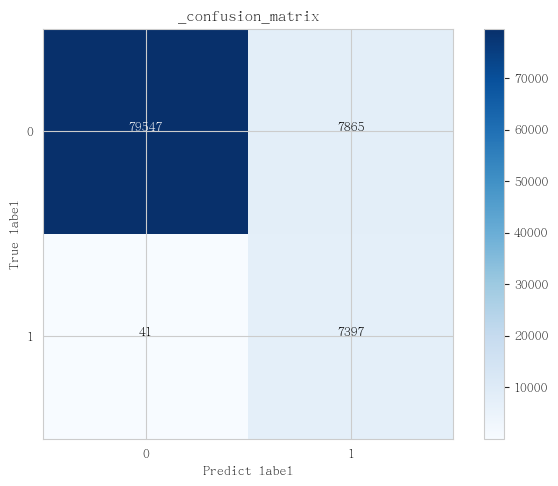

In [297]:
#默认阈值一般为0.5
y_pred_recall=y_pred[0:]>0.5
cnf_matrix=confusion_matrix(y_test,y_pred_recall)
class_names=[0,1]
plot_confusion_matrix(cnf_matrix,classes=class_names,fund_name='')

In [256]:
explainer=shap.Explainer(xgb_model)

In [257]:
shape_value=explainer.shap_values(X)
shap_df=pd.DataFrame(shape_value,columns=X_train_rus.columns)

In [258]:
# #输出每个特征的SHAP值（绝对值）
features=[]
shap_values_means=[]
for i,feature in enumerate(X_train_rus.columns):
    shap_values_mean=np.abs(shap_df.values[:,i]).mean()
    features.append(feature)
    shap_values_means.append(shap_values_mean)
tt=pd.DataFrame(features,columns=['features'])
tt['shap_values']=shap_values_means
tt_sort=tt.sort_values(by='shap_values',ascending=False)

In [259]:
tt_sort

,features,shap_values
171,S_FA_DEDUCTEDPROFIT,0.420314
288,CASH_PAY_DIST_DPCP_INT_EXP,0.385272
180,S_FA_RETAINEDPS,0.289601
510,VWAP0,0.226709
257,S_FA_ROE_YEARLY,0.196939
...,...,...
93,PLUS_NET_GAIN_FX_TRANS,0.000000
305,CASH_DEPOSITS_CENTRAL_BANK,0.000000
461,NET_INCR_LOANS_OTHER_BANK,0.000000
307,SPE_CUR_ASSETS_DIFF,0.000000


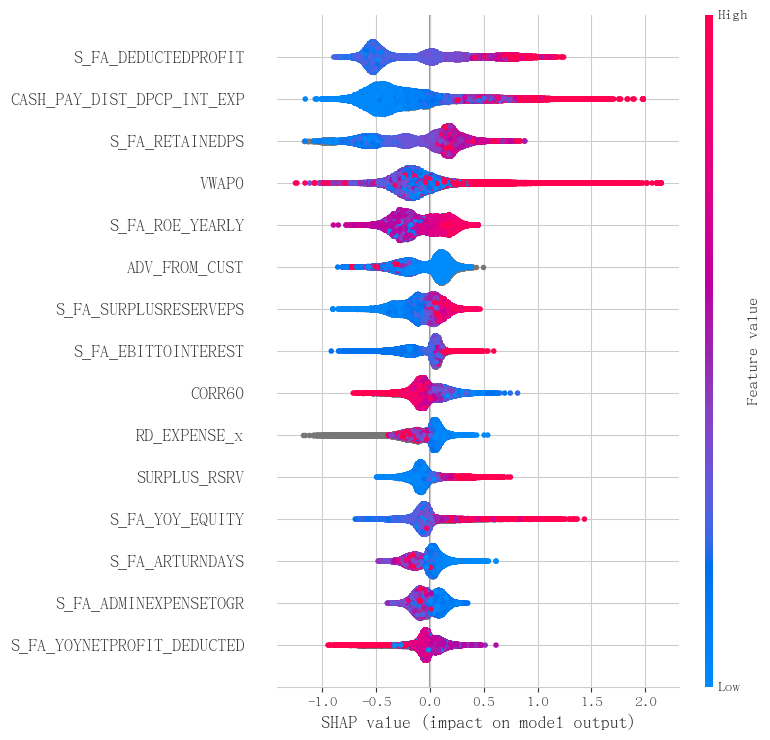

In [260]:
#摘要图，横轴：shap值，正的（正面影响）；纵轴：特征对模型预测贡献的平均绝对值排序；每个点代表一个样本，点的颜色表示该特征的值（红色表示特征值较高，蓝色表示特征值较低）
#正SHAP值表示该特征提高了对预测结果倾向于1的贡献
shape_value=explainer.shap_values(X)
shap.summary_plot(shape_value,X,max_display=15)

In [221]:
column_index = X.columns.get_loc('S_FA_YOY_EQUITY')

In [124]:
column_index

648

### 进一步分类，根据半年后股票收益率，判断高股息股票中的好与坏

In [400]:
result_df=result_df.reset_index(drop=True)
result_df

,Date,Stock_List
0,20150630,"[000488.SZ, 600809.SH, 601088.SH, 300469.SZ, 6..."
1,20151231,"[002440.SZ, 002419.SZ, 601566.SH, 000418.SZ, 6..."
2,20160630,"[002440.SZ, 600219.SH, 000002.SZ, 000418.SZ, 0..."
3,20161231,"[600704.SH, 000983.SZ, 000002.SZ, 603239.SH, 6..."
4,20170630,"[002440.SZ, 600009.SH, 002424.SZ, 000793.SZ, 6..."
5,20171231,"[002419.SZ, 600009.SH, 002424.SZ, 600704.SH, 0..."
6,20180630,"[002419.SZ, 600704.SH, 000002.SZ, 603989.SH, 6..."
7,20181231,"[002083.SZ, 002233.SZ, 002419.SZ, 600009.SH, 6..."
8,20190630,"[002233.SZ, 002083.SZ, 002419.SZ, 600009.SH, 6..."
9,20191231,"[002440.SZ, 002419.SZ, 002233.SZ, 002016.SZ, 6..."


In [401]:
dates_close=['20150630','20151231','20160630','20161230','20170630','20171229','20180628','20181228','20190628','20191231','20200630',
           '20201231','20210630','20211231','20220630','20221229','20230630','20231229','20240628','20241231']
dates_close_6=['20151230','20160630','20161230','20170630','20171229','20180629','20181228','20190628','20191227','20200630','20201230',
           '20210630','20211230','20220630','20221230','20230629','20231229','20240628','20241227','20250512']
data_close=[]
data_close_6=[]
for date in dates_close:
    connection = cx_Oracle.connect('jylh', 'jylh', '10.6.60.114:1521/wind')
    cursor = connection.cursor()
    sql = "select * from JY_QY_STOCKQUOTATION_CS where TRADEDATE= :date_param"
    cursor.execute(sql, (date,))
    columns = [col[0] for col in cursor.description]
    results = cursor.fetchall()
    close_df = pd.DataFrame(results, columns=columns)
    close_df=close_df[['TRADEDATE','STOCKCODE','CLOSE']]
    data_close.append(close_df)
    print(close_df.shape)
for date in dates_close_6:
    connection = cx_Oracle.connect('jylh', 'jylh', '10.6.60.114:1521/wind')
    cursor = connection.cursor()
    sql = "select * from JY_QY_STOCKQUOTATION_CS where TRADEDATE= :date_param"
    cursor.execute(sql, (date,))
    columns = [col[0] for col in cursor.description]
    results = cursor.fetchall()
    close_df_6 = pd.DataFrame(results, columns=columns)
    close_df_6=close_df_6[['TRADEDATE','STOCKCODE','CLOSE']]
    data_close_6.append(close_df_6)
    print(close_df_6.shape)
    

(2808, 3)
(2879, 3)
(2965, 3)
(3155, 3)
(3420, 3)
(3625, 3)
(3699, 3)
(3746, 3)
(3810, 3)
(3940, 3)
(4073, 3)
(4345, 3)
(4597, 3)
(4832, 3)
(4956, 3)
(5140, 3)
(5259, 3)
(5343, 3)
(5363, 3)
(5383, 3)
(2871, 3)
(2965, 3)
(3155, 3)
(3420, 3)
(3625, 3)
(3699, 3)
(3746, 3)
(3810, 3)
(3937, 3)
(4073, 3)
(4342, 3)
(4597, 3)
(4831, 3)
(4956, 3)
(5143, 3)
(5258, 3)
(5343, 3)
(5363, 3)
(5382, 3)
(5411, 3)


In [402]:
returns_list = []  # 用于存储每个日期的收益率DataFrame
i=0
for current_df, past_df in zip(data_close_6, data_close):
    # 合并当前和前六个月的数据，基于STOCKCODE
    merged = pd.merge(current_df, past_df, on='STOCKCODE', suffixes=('_current', '_past'))
    
    # 计算收益率: (当前收盘价 - 前六个月收盘价) / 前六个月收盘价
    merged['RETURN'] = (merged['CLOSE_current'] - merged['CLOSE_past']) / merged['CLOSE_past']
    
    # 选择需要的列
    result = merged[['TRADEDATE_past', 'STOCKCODE', 'RETURN']]
    result = result.rename(columns={'TRADEDATE_current': 'TRADEDATE'})
    
    result=result[result['STOCKCODE'].isin(result_df['Stock_List'][i])]
    i+=1
    returns_list.append(result)

In [403]:
returns_list

[     TRADEDATE_past  STOCKCODE    RETURN
 8          20150630  601088.SH -0.277572
 15         20150630  601877.SH -0.144541
 29         20150630  000778.SZ -0.491494
 31         20150630  000858.SZ -0.130595
 264        20150630  600309.SH -0.264279
 ...             ...        ...       ...
 2683       20150630  000402.SZ -0.140845
 2745       20150630  002771.SZ  5.188241
 2768       20150630  600019.SH -0.360819
 2774       20150630  600123.SH -0.317967
 2796       20150630  601369.SH -0.241912
 
 [67 rows x 3 columns],
      TRADEDATE_past  STOCKCODE    RETURN
 14         20151231  000828.SZ -0.261512
 30         20151231  002372.SZ  0.076449
 64         20151231  600177.SH -0.106428
 85         20151231  600886.SH -0.209587
 110        20151231  000402.SZ -0.156982
 ...             ...        ...       ...
 2631       20151231  002039.SZ -0.002268
 2646       20151231  002311.SZ  0.145160
 2678       20151231  000690.SZ -0.286698
 2732       20151231  600183.SH -0.032650
 2804   

### 计算中证800收益率

In [492]:
connection = cx_Oracle.connect('jylh', 'jylh', '10.6.60.114:1521/wind')
cursor = connection.cursor()
sql = "select TRADEDATE,TCLOSE from JY_QY_INDEXDATA_CS where INDEXCODE='2070003752' and TRADEDATE>='20150630' order by TRADEDATE asc"
cursor.execute(sql,)
columns = [col[0] for col in cursor.description]
results = cursor.fetchall()
close_800 = pd.DataFrame(results, columns=columns)
print(close_800.shape)

(2396, 2)


In [493]:
close_800

,TRADEDATE,TCLOSE
0,20150630,14601.0625
1,20150701,13711.0673
2,20150702,12696.0401
3,20150703,11768.4337
4,20150706,11829.2642
...,...,...
2391,20250507,16489.2476
2392,20250508,16495.9472
2393,20250509,16539.3927
2394,20250512,16620.5409


In [494]:
# 提取当前日期的收盘价
current_data = close_800[close_800["TRADEDATE"].isin(dates_close_6)][["TRADEDATE", "TCLOSE"]]
current_data = current_data.rename(columns={"TCLOSE": "CLOSE_CURRENT"})
current_data = current_data.reset_index(drop=True)

# 提取过去六个月的收盘价
past_data = close_800[close_800["TRADEDATE"].isin(dates_close)][["TRADEDATE", "TCLOSE"]]
past_data = past_data.rename(columns={"TCLOSE": "CLOSE_PAST"})
past_data = past_data.reset_index(drop=True)

In [495]:
# 计算收益率：(当前价格 - 过去价格) / 过去价格
returns=[]
for current_price,past_price in zip(current_data['CLOSE_CURRENT'],past_data['CLOSE_PAST']):
    returns.append((current_price-past_price)/past_price)

# # 保留需要的列
# result_800 = merged_data[["TRADEDATE", "CLOSE_CURRENT", "CLOSE_PAST", "RETURN"]]

In [496]:
returns

[-0.1304476506418626,
 -0.18596663370816843,
 0.10084255513696176,
 0.008366675653258054,
 0.015711144056233063,
 -0.14142549923350003,
 -0.0592985201038834,
 0.16768096754421033,
 -0.011839893495018449,
 -0.01910362080304087,
 0.07977505457802328,
 0.1699193666923318,
 0.03403841356791832,
 0.017563537460962727,
 -0.03149429014965011,
 0.07779550031984594,
 0.02016947295737938,
 0.10017532404883772,
 0.05334064393210115,
 -0.03739480181035463]

### 根据中证100收益率对高股息股票进行打标签

In [497]:
for df, value in zip(returns_list, returns):
    # 添加新列 label，根据股票收益率与中证800收益率比较打标签
    df['label'] = (df['RETURN'] >= value).astype(int)
    
    # 可选：打印处理后的数据形状和对应的中证800收益率
    print(f"DataFrame Shape: {df.shape}, CSI800 Return: {value}")

DataFrame Shape: (67, 4), CSI800 Return: -0.1304476506418626
DataFrame Shape: (89, 4), CSI800 Return: -0.18596663370816843
DataFrame Shape: (112, 4), CSI800 Return: 0.10084255513696176
DataFrame Shape: (107, 4), CSI800 Return: 0.008366675653258054
DataFrame Shape: (170, 4), CSI800 Return: 0.015711144056233063
DataFrame Shape: (176, 4), CSI800 Return: -0.14142549923350003
DataFrame Shape: (196, 4), CSI800 Return: -0.0592985201038834
DataFrame Shape: (188, 4), CSI800 Return: 0.16768096754421033
DataFrame Shape: (222, 4), CSI800 Return: -0.011839893495018449
DataFrame Shape: (235, 4), CSI800 Return: -0.01910362080304087
DataFrame Shape: (297, 4), CSI800 Return: 0.07977505457802328
DataFrame Shape: (411, 4), CSI800 Return: 0.1699193666923318
DataFrame Shape: (467, 4), CSI800 Return: 0.03403841356791832
DataFrame Shape: (593, 4), CSI800 Return: 0.017563537460962727
DataFrame Shape: (638, 4), CSI800 Return: -0.03149429014965011
DataFrame Shape: (488, 4), CSI800 Return: 0.07779550031984594
Da

In [498]:
#拼接DataFrame
combined_df_800 = pd.concat(returns_list, axis=0, ignore_index=True)

In [499]:
combined_df.head()

,S_FA_ADMINEXPENSETOGR,S_FA_ROA_YEARLY,NET_CASH_FLOWS_INV_ACT,BETA5,RSV30,PLUS_NET_INVEST_INC,S_FA_BPS,TOT_COMPREH_INC_PARENT_COMP,LENDING_FUNDS,RSV5,...,S_FA_ORPS,STD5,S_FA_GRPS,CASH_PREPAY_AMT_BORR,CNTP60,EFF_FX_FLU_CASH,MINORITY_INT,S_FA_YOYASSETS,S_QFA_YOYGR,CNTP5
0,32.2169,0.9742,-4.991300e+10,-0.016988,0.380845,2.104000e+09,10.5444,1.197900e+10,NaN,0.621512,...,3.2549,0.046866,3.2549,5.838000e+10,0.516667,-1.700000e+08,NaN,17.5649,39.0222,0.4
1,2.8214,2.5980,-3.530658e+09,-0.001584,0.498554,9.156905e+08,7.8994,4.782648e+09,NaN,0.877555,...,4.5498,0.032047,4.5498,1.099352e+10,0.500000,5.355235e+05,3.052716e+10,5.6114,31.4886,0.6
2,13.1806,2.5682,-4.703863e+06,-0.011268,0.428593,-1.278559e+05,0.9704,1.212220e+06,NaN,0.709175,...,0.7091,0.051248,0.7091,NaN,0.616667,NaN,8.030711e+07,3.0678,139.3469,0.6
3,72.0399,-3.4248,-6.055045e+06,-0.063493,0.130285,NaN,0.7071,-2.318851e+07,NaN,0.322773,...,0.0397,0.108523,0.0397,2.450000e+07,0.383333,NaN,NaN,-1.8341,95.2896,0.6
4,1.2181,4.5636,-4.029753e+08,-0.051876,0.345855,-1.710140e+05,3.1366,2.592168e+08,NaN,0.465198,...,1.4982,0.099564,1.4982,7.670000e+08,0.583333,-1.259050e+03,9.030923e+07,0.1479,177.1079,0.4


In [500]:
combined_df_800.head()

,TRADEDATE_past,STOCKCODE,RETURN,label
0,20150630,601088.SH,-0.277572,0
1,20150630,601877.SH,-0.144541,0
2,20150630,000778.SZ,-0.491494,0
3,20150630,000858.SZ,-0.130595,0
4,20150630,600309.SH,-0.264279,0


In [413]:
combined_df_800.to_csv('high_dividend_test.csv',index=False)

In [414]:
combined_df_800[3330:]

,TRADEDATE_past,STOCKCODE,RETURN,label
3330,20220630,002567.SZ,-0.167966,0
3331,20220630,300082.SZ,-0.329380,0
3332,20220630,300146.SZ,0.054049,1
3333,20220630,300314.SZ,0.222195,1
3334,20220630,300402.SZ,0.131805,1
...,...,...,...,...
7198,20241231,603993.SH,0.094738,1
7199,20241231,603995.SH,-0.096775,0
7200,20241231,603997.SH,0.112665,1
7201,20241231,603998.SH,-0.075717,0


### 标签与前面特征数据拼接

In [501]:
combined_df1=combined_df.drop(columns=['label'])

In [502]:
print(combined_df1.shape)

(94850, 582)


In [503]:
merged_800_df=pd.merge(combined_df_800, combined_df1, left_on=['TRADEDATE_past','STOCKCODE'], right_on=['DATETIME','CODE'],
                                  how='left')

In [546]:
merged_800_df[5320:]
# merged_800_df.shape

,TRADEDATE_past,STOCKCODE,RETURN,label,S_FA_ADMINEXPENSETOGR,S_FA_ROA_YEARLY,NET_CASH_FLOWS_INV_ACT,BETA5,RSV30,PLUS_NET_INVEST_INC,...,S_FA_ORPS,STD5,S_FA_GRPS,CASH_PREPAY_AMT_BORR,CNTP60,EFF_FX_FLU_CASH,MINORITY_INT,S_FA_YOYASSETS,S_QFA_YOYGR,CNTP5
5320,20231229,300938.SZ,-0.206189,0,16.7423,9.7219,-7.248214e+08,0.004625,0.553715,5.225162e+06,...,5.9706,0.009249,5.9706,8.000000e+06,0.416667,5.185090e+04,7.630574e+07,45.6409,17.1126,0.6
5321,20231229,300970.SZ,-0.325464,0,8.7687,1.2865,-1.225766e+08,0.011240,0.408446,5.402437e+05,...,8.4505,0.019548,8.4505,1.295612e+08,0.483333,NaN,2.028585e+07,6.9991,9.5358,0.6
5322,20231229,301126.SZ,-0.304125,0,2.8062,0.8255,-7.988448e+08,0.008826,0.401641,-1.496085e+05,...,18.9026,0.016731,18.9026,1.289080e+09,0.483333,8.300000e-01,3.441861e+07,34.2429,7.0210,0.6
5323,20231229,600050.SH,0.073058,0,8.6144,2.8623,-8.553928e+10,0.011188,0.572440,4.805675e+09,...,11.7154,0.019467,11.7154,5.932549e+09,0.333333,1.048561e+08,1.986945e+11,2.8165,-0.0679,0.8
5324,20231229,600210.SH,0.131916,1,10.4130,4.7696,-1.019512e+09,0.007021,0.416659,4.609116e+07,...,6.0100,0.015089,6.0100,3.268554e+09,0.366667,-8.268361e+05,4.860254e+08,13.3941,-24.3648,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7587,20241231,603993.SH,0.094738,1,1.1649,9.0087,-1.159650e+09,-0.009323,0.000000,9.588052e+08,...,9.8628,0.016933,9.8628,8.288344e+10,0.416667,5.066716e+08,1.491924e+10,-1.5829,6.7550,0.2
7588,20241231,603995.SH,-0.096775,0,2.6030,7.1434,-1.142986e+09,-0.004647,0.082953,-1.133981e+06,...,114.4937,0.013911,114.4937,2.942118e+09,0.466667,1.145215e+07,1.122806e+09,14.4711,-11.1724,0.2
7589,20241231,603997.SH,0.112665,1,11.8175,-3.5567,-1.586532e+09,-0.032053,0.016488,-1.645235e+07,...,17.5783,0.052465,17.5783,3.847557e+09,0.450000,-7.062700e+07,2.570324e+08,12.9940,-5.0281,0.2
7590,20241231,603998.SH,-0.075717,0,16.0374,7.8723,4.104359e+07,-0.001728,0.040985,3.855737e+07,...,4.0478,0.011910,4.0478,8.838862e+08,0.433333,6.700000e-01,1.119029e+08,6.0237,3.8445,0.4


In [505]:
X=merged_800_df.drop(columns=['CODE','label','DATETIME','TRADEDATE_past','STOCKCODE','RETURN'])
y=merged_800_df['label']
y_code_pn=merged_800_df[['CODE','DATETIME']]

In [625]:
#训练集测试集划分，训练集放入全部正样本，负样本进行欠采样，预测时放入全部样本,3620为20220630分割点
#保留正样本，欠采样负样本
rus=RandomUnderSampler(sampling_strategy=1) #比例1：10
# X_train_rus,y_train_rus=rus.fit_resample(X,y)
# X_test,y_test=X,y
X_train_rus,y_train_rus=X[2000:3620],y[2000:3620]
X_test,y_test=X[3620:],y[3620:]

In [615]:
print(X_train_rus.shape)
print(y_train_rus.shape)
print(X_test.shape)
print(y_test.shape)

(1120, 580)
(1120,)
(3972, 580)
(3972,)


In [616]:
#统计当前类别占比情况
print("Before undersampling:",Counter(y))

Before undersampling: Counter({0: 4538, 1: 3054})


In [617]:
#欠采样后类别占比情况
print("After undersampling:",Counter(y_train_rus))

After undersampling: Counter({0: 829, 1: 291})


In [648]:
#XGBoost模型定义与训练
xgb_model=XGBClassifier(max_depth=3,max_leaves=8,n_estimators=128)
xgb_model.fit(X_train_rus,y_train_rus)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=8,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=128, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [652]:
booster=xgb_model.get_booster()
# for i in range(xgb_model.n_estimators):
#     num_leaves=booster.get_num_leaves(i)
#     print(f"Tree{i}:{num_leaves}leaves")
print(booster.get_dump())

0:[S_QFA_YOYNETPROFIT<-19.0608997] yes=1,no=2,missing=2
	1:[PROJ_MATL<20149924] yes=3,no=4,missing=4
		3:[S_FA_YOYEQUITY<14.9933004] yes=7,no=8,missing=8
			7:leaf=0.227484122
			8:leaf=-0.251658678
		4:[S_FA_TANGIBLEASSETTONETDEBT<1.6437] yes=9,no=10,missing=10
			9:leaf=0.046990972
			10:leaf=-0.330976337
	2:[S_FA_TANGASSETTOINTDEBT<2.63439989] yes=5,no=6,missing=6
		5:[RSQR60<0.0677812025] yes=11,no=12,missing=12
			11:leaf=-0.114902869
			12:leaf=0.359228313
		6:[ROC10<0.914762855] yes=13,no=14,missing=14
			13:leaf=0.244065791
			14:leaf=-0.051907707


In [639]:
clf=DecisionTreeClassifier(max_depth=12,random_state=42)
clf.fit(X_train_rus,y_train_rus)
y_pred=clf.predict(X_test[1000:])
metric_score(test_y=y_test[1000:],pre_y=y_pred)

Recall:0.198
Precision:0.456
F1:0.276


In [640]:
y_pred=clf.predict(X_train_rus)
metric_score(test_y=y_train_rus,pre_y=y_pred)

Recall:0.564
Precision:0.912
F1:0.697


In [650]:
#XGBoost模型评估,Recall:实际为正类样本中被正确预测为正类的比例，Precision：预测为正类的样本中实际为正类的比例，F1：2×（（recall×precision）/（recall+precision））
y_pred=xgb_model.predict(X_test[1000:])
metric_score(test_y=y_test[1000:],pre_y=y_pred)
# y_pred=xgb_model.predict(X_train_rus)
# metric_score(test_y=y_train_rus,pre_y=y_pred)

Recall:0.148
Precision:0.460
F1:0.224


In [637]:
y_pred=xgb_model.predict(X_train_rus)
metric_score(test_y=y_train_rus,pre_y=y_pred)

Recall:1.000
Precision:1.000
F1:1.000


In [513]:
y_code_pn=y_code_pn[3620:].reset_index(drop=True)
y_code_pn

,CODE,DATETIME
0,002567.SZ,20220630
1,300082.SZ,20220630
2,300146.SZ,20220630
3,300314.SZ,20220630
4,300402.SZ,20220630
...,...,...
3967,603993.SH,20241231
3968,603995.SH,20241231
3969,603997.SH,20241231
3970,603998.SH,20241231


In [514]:
print(len(y_code_pn))

3972


In [490]:
y_pred_df=pd.DataFrame(y_pred,columns=['pred_label'])
pred_df = y_code_pn.join(y_pred_df)
print(pred_df.head())
print(pred_df.shape)

        CODE  DATETIME  pred_label
0  002567.SZ  20220630           1
1  300082.SZ  20220630           0
2  300146.SZ  20220630           0
3  300314.SZ  20220630           0
4  300402.SZ  20220630           1
(3972, 3)


In [491]:
pred_df.to_csv('high_dividend_test.csv',index=False)

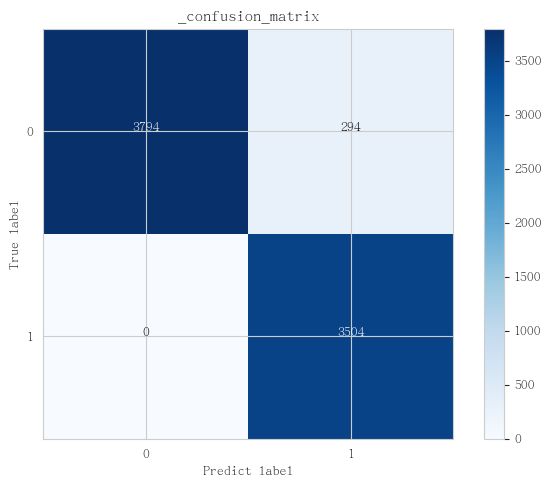

In [346]:
#默认阈值一般为0.5
y_pred_recall=y_pred[0:]>0.5
cnf_matrix=confusion_matrix(y_test,y_pred_recall)
class_names=[0,1]
plot_confusion_matrix(cnf_matrix,classes=class_names,fund_name='')

In [519]:
explainer=shap.Explainer(xgb_model)
shape_value=explainer.shap_values(X)
shap_df=pd.DataFrame(shape_value,columns=X_train_rus.columns)

In [520]:
# #输出每个特征的SHAP值（绝对值）
features=[]
shap_values_means=[]
for i,feature in enumerate(X_train_rus.columns):
    shap_values_mean=np.abs(shap_df.values[:,i]).mean()
    features.append(feature)
    shap_values_means.append(shap_values_mean)
tt=pd.DataFrame(features,columns=['features'])
tt['shap_values']=shap_values_means
tt_sort=tt.sort_values(by='shap_values',ascending=False)

In [521]:
tt_sort

,features,shap_values
575,EFF_FX_FLU_CASH,0.351867
392,S_QFA_YOYPROFIT,0.196482
410,ROC5,0.192502
202,S_QFA_YOYOP,0.176997
432,LESS_IMPAIR_LOSS_ASSETS,0.174820
...,...,...
272,LOANS_AND_ADV_GRANTED,0.000000
197,SUMN20,0.000000
456,TOT_LIAB_SHRHLDR_EQY,0.000000
461,NET_INCR_LOANS_OTHER_BANK,0.000000


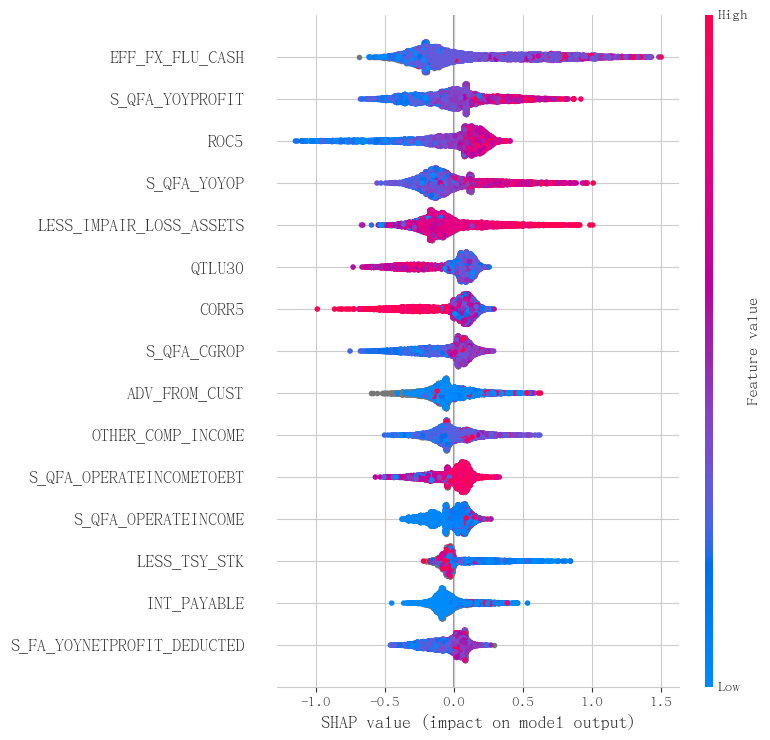

In [522]:
#摘要图，横轴：shap值，正的（正面影响）；纵轴：特征对模型预测贡献的平均绝对值排序；每个点代表一个样本，点的颜色表示该特征的值（红色表示特征值较高，蓝色表示特征值较低）
#正SHAP值表示该特征提高了对预测结果倾向于1的贡献
shape_value=explainer.shap_values(X)
shap.summary_plot(shape_value,X,max_display=15)

### 把第一步中标签为0，预测标签为1的数据也加入训练

In [379]:
df=positive_df[positive_df['pred_label']==1]

In [384]:
# 按照DATETIME列进行分组，并将CODE合并成列表，同时去重
df_grouped = df.groupby('DATETIME')['CODE'].apply(lambda x: list(set(x))).reset_index()

# 更改列名以符合要求
df_grouped.columns = ['Date', 'Stock_list']

In [385]:
df_grouped

,Date,Stock_list
0,20150630,"[002440.SZ, 600009.SH, 600606.SH, 600196.SH, 6..."
1,20151231,"[002440.SZ, 002419.SZ, 600009.SH, 002424.SZ, 3..."
2,20160630,"[002440.SZ, 002419.SZ, 600009.SH, 600704.SH, 6..."
3,20161230,"[002419.SZ, 600009.SH, 600704.SH, 002831.SZ, 6..."
4,20170630,"[002440.SZ, 600009.SH, 600704.SH, 601566.SH, 0..."
5,20171229,"[601019.SH, 000703.SZ, 000418.SZ, 603989.SH, 6..."
6,20180628,"[002440.SZ, 002419.SZ, 600704.SH, 002262.SZ, 6..."
7,20181228,"[002233.SZ, 601019.SH, 000983.SZ, 603260.SH, 0..."
8,20190628,"[002233.SZ, 002440.SZ, 601019.SH, 600500.SH, 0..."
9,20191231,"[002233.SZ, 002440.SZ, 300790.SZ, 000026.SZ, 0..."


In [386]:
len(df_grouped['Stock_list'][0])

175

### 测试集当训练集再训练一个模型

In [527]:
rus=RandomUnderSampler(sampling_strategy=1) #比例1：10
X_train_rus1,y_train_rus1=rus.fit_resample(X_test,y_test)
# X_train_rus1,y_train_rus1=X_test,y_test
X_test1,y_test1=X_test,y_test

In [528]:
#统计当前类别占比情况
print("Before undersampling:",Counter(y_test))

Before undersampling: Counter({0: 2313, 1: 1659})


In [529]:
#XGBoost模型定义与训练
xgb_model=XGBClassifier()
xgb_model.fit(X_train_rus1,y_train_rus1)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [530]:
#XGBoost模型评估,Recall:实际为正类样本中被正确预测为正类的比例，Precision：预测为正类的样本中实际为正类的比例，F1：2×（（recall×precision）/（recall+precision））
y_pred1=xgb_model.predict(X_test1)
metric_score(test_y=y_test1,pre_y=y_pred1)

Recall:1.000
Precision:0.899
F1:0.947


In [531]:
explainer=shap.Explainer(xgb_model)
shape_value=explainer.shap_values(X)
shap_df=pd.DataFrame(shape_value,columns=X_train_rus.columns)

In [532]:
# #输出每个特征的SHAP值（绝对值）
features=[]
shap_values_means=[]
for i,feature in enumerate(X_train_rus.columns):
    shap_values_mean=np.abs(shap_df.values[:,i]).mean()
    features.append(feature)
    shap_values_means.append(shap_values_mean)
tt=pd.DataFrame(features,columns=['features'])
tt['shap_values']=shap_values_means
tt_sort=tt.sort_values(by='shap_values',ascending=False)
tt_sort

,features,shap_values
277,VSUMN60,0.240661
181,S_FA_YOYROE,0.184525
123,S_FA_YOY_EQUITY,0.183461
392,S_QFA_YOYPROFIT,0.153502
310,RESI5,0.152223
...,...,...
145,OTHER_BUS_COST,0.000000
483,PREM_RECEIVED_ADV,0.000000
229,FA_FNC_LEASES,0.000000
266,CLIENTS_RSRV_SETTLE,0.000000
